# O modelo do neurônio

## O perceptron de Rosenblatt


Para introduzir o perceptron de Rosenblatt, vamos voltar ao exemplo das meias-luas, em que o algoritmo LMS foi utilizado para classificar os dados como pertencentes à Região A ou Região B, como mostrado na Figura

```{figure} ./images/meiasluas.png
---
height: 300px
name: fig_meiasluas_2
---
O problema de classificação das meias-luas.
```

Para $r_1=10$, $r_2=1$, $r_3=6$, $\mu=10^{-4}$ e $M=2$, a saída do LMS no modo estocástico ($N_t=1000$, $N_b=1$ e $N_e=1$) está mostrada na Figura~\ref{fig:SaidaLMS}. Nesta aplicação, considerou-se como sinal desejado $d=+1$ para dados  pertencentes à Região A e $d=-1$ para os pertencentes à Região B. Depois de 1000 iterações, o LMS consegue classificar os dados com uma taxa de erros de aproximadamente 2,5\% com sua reta de separação entre as regiões. Apesar disso, a saída do algoritmo fica espalhada no intervalo $[-1,5\;\; 1,5]$, não havendo uma clara separação em torno do zero.

```{figure} ./images/SaidaLMS.png
---
width: 100%
name: fig_SaidaLMS
---
Saída do algoritmo LMS ($\eta=10^{-4}$ e $M=2$) durante o treinamento no modo estocástico ($N_t=1000$, $N_b=1$ e $N_e=1$) utilizado  no problema de classificação das meias-luas ($r_1=10$, $r_2=1$ e $r_3=6$).
```

Diferente do LMS, o perceptron de Rosenblatt força a saída $y(n)$ a assumir valores do conjunto $\{-1,\; +1\}$. Para isso, ele introduz uma função não linear $\varphi(\cdot)$ à saída do combinador. No caso, a função $\varphi(\cdot)$ é um limitador abrupto (*hard limiter*), dado por

$$
\varphi(v)=\text{sgn}(v)=\left\{\begin{array}{cc}
                      +1, & v\geq 0 \\
                      -1, & v<0
                    \end{array},
\right.
$$

em que $\text{sgn}(\cdot)$ representa a função sinal, como mostrado na {numref}`fig_Sinal`.


```{figure} ./images/Sinal.png
---
width: 300px
name: fig_Sinal
---
Função sinal.
```

Considerando o $n$-ésimo vetor dos dados de treinamento

$$
\mathbf{x}(n)=[\,1\;x_{1n}\; x_{2n}\; \cdots\; x_{Mn}\,]^{\rm T}
$$

e o vetor de pesos com dimensão $M+1$

$$
\mathbf{w}(n) = [\,b(n)\;w_1(n)\;\cdots\;w_M(n)\,]^{\rm T},
$$

a saída do combinador linear pode ser escrita como

$$
v(n) = \mathbf{x}^{\rm T}(n)\mathbf{w}(n-1)
$$

e a saída do perceptron de Rosenblatt é dada por

$$
y(n)=\varphi(v(n))=\text{sgn}(v(n)).
$$

Observe que devido à função sinal, $y(n)\in \{-1,\;+1\}$. O diagrama de fluxo de sinal do perceptron de Rosenblatt está mostrado na {numref}`fig_Rosenblatt`.

```{figure} ./images/Rosenblatt.png
---
height: 300px
name: fig_Rosenblatt
---
Fluxo de sinal do perceptron de Rosenblatt.
```

Como no algoritmo LMS, os pesos são atualizados para  minimizar o erro quadrático $e^2(n)$, em que

$$
e(n)=d(n)-\varphi(\mathbf{x}^{\rm T}(n)\mathbf{w}(n-1))=d(n)-{\text{sgn}}(v(n))=d(n)-y(n).
$$

Observe que $e(n)$ assume agora três valores possíveis: $-2$ ou $+2$ quando $d(n)\neq y(n)$ e $0$ quando $d(n)=y(n)$. Como a função sinal não é derivável em todos os pontos, não é possível obter o algoritmo de maneira formal, como feito na dedução do algoritmo LMS.
Além disso, note que

$$
\frac{\partial e(n)}{\partial \mathbf{w}(n-1)}=-\frac{\partial \text{sgn}(\mathbf{x}^{\rm T}(n)\mathbf{w}(n-1))}{\partial \mathbf{w}(n-1)}=-\mathbf{x}(n)\,{\text{sgn}'}(v(n))=\left\{\begin{array}{cc}
                                         \boldsymbol{0}, & v(n)\neq 0 \\
                                         \nexists, & v(n)=0. \\
                                       \end{array}
\right.
$$

Ignorando o fato da derivada não existir para $v(n)=0$, os pesos não seriam atualizados se utilizássemos esse resultado, uma vez que o vetor gradiente é nulo para $v(n)\neq 0$. Por isso, utiliza-se a equação de atualização

$$
\mathbf{w}(n)=\mathbf{w}(n-1)+\eta e(n)\mathbf{x}(n).
$$

Assim, os pesos são atualizados apenas quando $e(n)\neq 0$, ou seja, quando  $y(n)\neq d(n)$. Caso contrário, $\mathbf{w}(n)=\mathbf{w}(n-1)$. O passo de adaptação $\eta$, também chamado de taxa de aprendizado, é uma constante positiva que deve ser escolhida no intervalo $0<\eta\leq 1$. Como no caso do LMS, a escolha desse passo deve sempre levar em conta o compromisso entre estimativas mais precisas dos pesos e velocidade de aprendizado. A prova de convergência desse algoritmo para $\eta=1$ pode ser encontrada, por exemplo, em [Haykin, 2009]. Considerando a formulação matricial e o modo de treinamento *mini-batch*, o pseudocódigo do  algoritmo de treinamento do perceptron de Rosenblatt é mostrado na {numref}`tab_Rosenblatt`.


```{list-table} Sumário do algoritmo de treinamento do perceptron de Rosenblatt no modo *mini-batch*. $N_e$ é o número de épocas, $N_b$ o tamanho do mini-batch e $N_t$ o número de dados de treinamento
:header-rows: 0
:name: tab_Rosenblatt

* - Inicialização:    
    - $\mathbf{w}(0)=\boldsymbol{0}$, $m=0$
* - Para $k=1, 2, \ldots, N_e$ calcule:
    - Misture os dados de treinamento
    - Para $\ell=0, 1, 2, \ldots, \lfloor N_t/N_b \rfloor - 1$ calcule:
      - $\mathbf{v}(\ell)=\mathbf{X}(\ell)\mathbf{w}(\ell)$
      - $\mathbf{y}(\ell)=\text{sgn}(\mathbf{v}(\ell))$
      - $\mathbf{e}(\ell)=\mathbf{d}(\ell)-\mathbf{y}(\ell)$
      - $\mathbf{w}(m+1)=\mathbf{w}(m)+\displaystyle\frac{\eta}{N_b}\mathbf{X}^{\rm T}(\ell)\mathbf{e}(\ell)$
      - $m\leftarrow m+1$
```

Voltando ao exemplo das meias-luas, vamos considerar agora a solução obtida pelo perceptron de Rosenblatt no modo de treinamento *batch* com $M=2$, $\eta=0,001$, $N_t=1000$, $N_b=N_t$ e $N_e=50$. Na {numref}`fig_JMSESepd1` são mostrados a função custo ao longo das épocas, os dados de teste  e reta de separação das regiões no caso de $r_2=1$. Observa-se neste caso que a função custo converge para zero e a reta de separação obtida proporciona uma solução com taxa de erro nula. Para $r_2=-4$, uma condição que viola a separabilidade linear,  os resultados estão mostrados na {numref}`fig_JMSESepdm4`. Neste caso, observa-se que a função custo não converge mais para zero. Ela varia continuamente, indicando o ``colapso'' do algoritmo. Isso faz com que pontos da Região A sejam classificados erroneamente como pertencentes à Região B e vice-versa, o que leva a uma taxa de erro de aproximadamente $12,8\%$.


```{figure} ./images/JMSESepd1.png
---
width: 100%
name: fig_JMSESepd1
---
O problema de classificação das meias-luas ($r_1=10$, $r_2=1$ e $r_3=6$). Função custo ao longo das épocas de treinamento  (figura à esquerda); Dados de teste  ($N_{\text{teste}}=2000$) e reta de separação das regiões (figura à direita) obtida com o perceptron de Rosenblatt treinado em *batch* ($M=2$, $\eta=0,001$, $N_t=1000$, $N_b=N_t$ e $N_e=50$).
```


```{figure} ./images/JMSESepdm4.png
---
width: 100%
name: fig_JMSESepdm4
---
O problema de classificação das meias-luas ($r_1=10$, $r_2=-4$ e $r_3=6$). Função custo ao longo das épocas de treinamento (figura à esquerda); Dados de teste  ($N_{\text{teste}}=2000$) e reta de separação das regiões  (figura à direita) obtida com o perceptron de Rosenblatt treinado em *batch* ($M=2$, $\eta=0,001$, $N_t=1000$, $N_b=N_t$ e $N_e=50$).
```

Comparando o perceptron de Rosenblatt com o algoritmo LMS, percebe-se que ambos podem ser descritos pelo modelo da {numref}`fig_Rosenblatt`. A única diferença é a função utilizada na saída do combinador linear. Como vimos, no perceptron de Rosenblatt utiliza-se $\varphi(v)={\rm sgn}(v)$, enquanto no LMS considera-se $\varphi(v)=v$. Em termos de convergência, o sinal de erro utilizado no perceptron de Rosenblatt é limitado, pois $e(n)\in \{-2,\; 0,\; 2\}$, o que não ocorre no algoritmo LMS. Isso faz com que o perceptron de Rosenblatt não sofra divergência desde que as entradas sejam limitadas. O mesmo não se pode afirmar sobre o algoritmo LMS, pois o sinal de erro não é limitado. Dependendo do valor do passo de adaptação $\eta$, o erro e consequentemente os pesos podem divergir. Apesar dessa diferença, ambos levam a fronteiras de separação que são retas (ou hiperplanos no caso em que $M>2$). Essas soluções são boas apenas quando há separabilidade linear, o que no exemplo das meias-luas ocorre para $r_1=1$, mas não ocorre para $r_2=-4$. Para  gerar uma fronteira não linear, podemos usar uma rede neural, como será visto posteriormente. A seguir, vamos ver que o perceptron de Rosenblatt é um dos primeiros modelos de neurônio, unidade básica de uma rede neural.


## O neurônio biológico e um pouco de história

No início do século passado, o médico e histologista espanhol Ramón y Cajál foi o primeiro a introduzir a ideia dos neurônios como unidades básicas do sistema nervoso. Os neurônios são  células altamente especializadas na transmissão de informações na forma de pulsos nervosos. As ligações entre os neurônios são chamadas de sinapses, que tem por função enviar sinais por transmissões sinápticas para ocorrer ações específicas no corpo. A taxa dessas  transmissões é considerada baixa quando comparada com portas lógicas de silício. Eventos em um chip de silício acontecem na faixa de nanossegundos, enquanto os eventos neurais acontecem na faixa de milissegundos. No entanto, essa taxa ``baixa'' é compensada pelo impressionante número de neurônios existentes no sistema nervoso humano, estimado em mais de 86 bilhões. Em termos de sinapses, esse número aumenta para mais de 60 trilhões. O resultado final é que o cérebro é uma estrutura extremamente eficiente.

O neurônio biológico está esquematizado na {numref}`fig_neuron`. A atividade do neurônio é caracterizada por pulsos elétricos da ordem de milivolts e duração da ordem de milissegundos. Ele recebe esses pulsos de outros neurônios pelos seus dendritos. Se o sinal acumulado exceder um certo valor, um pulso é enviado via axônio aos seus terminais, que por sua vez, se acoplam a outros neurônios. Grosso modo, a computação realizada por um neurônio na sua saída (no seu axônio) pode ser  resumida na frequência dos pulsos. Se houver poucos pulsos por unidade de tempo, o neurônio é considerado pouco ativo. Em contrapartida, se ele tiver muitos pulsos por unidade de tempo, haverá mais estímulos sinápticos e o músculo que o neurônio controla, por exemplo, é forçado a uma atividade maior.

```{figure} ./images/neuron.png
---
width: 100%
name: fig_neuron
---
Neurônio biológico. Fonte: adaptado de [O. Dürr, B. Sick, E. Murina: *Probabilist Deep Learning*, Manning, 2020].
```

Redes neurais surgiram para buscar modelar o cérebro humano.
Nos anos de surgimento das redes neurais (1943-1960), vários pesquisadores se destacam por suas contribuições pioneiras:

1. McCulloch e Pitts (1943) por introduzirem a ideia de redes neurais como máquinas de computação;
2. Hebb (1949) por postular a primeira regra de aprendizagem auto-organizada;
3. Rosenblatt (1958) por propor o perceptron como o primeiro modelo de aprendizagem supervisionada;
4. Widrow e Hoff (1960) por propor o Adaline (*adaptive linear element*), que deu origem ao algoritmo LMS.

Inspirado no funcionamento do neurônio biológico, Rosenblatt propôs o modelo de neurônio artificial, chamado de perceptron, como ilustrado na {numref}`fig_Rosenblatt`. O neurônio biológico recebe vários estímulos de outros neurônios que chegam por seus dendritos, esses estímulos são então acumulados e se exceder um limiar, o neurônio gera um estímulo no seu axônio que são transmitidos a outros neurônios. No modelo matemático de Rosenblatt, esses estímulos  são representados pelo vetor de entrada $\mathbf{x}(n)$ e o acúmulo dos estímulos pela soma ponderada da entrada com os pesos, gerando o sinal $v(n)$. Se $v(n)<0$, o neurônio estará em repouso. Caso contrário, estará ativo e um novo estímulo, representado por  $y(n)$, é gerado. Aqui cabe uma observação: para representar o neurônio em repouso, talvez fosse mais adequado considerar a função degrau (função de Heaviside) em vez da função sinal. Assim, $y(n)=0$ para $v(n)<0$. No entanto, pensando na implementação do modelo com um circuito analógico, pode ser mais adequado considerar uma tensão negativa em vez de uma tensão nula para representar o repouso e para isso, a função sinal se mostrou mais adequada.

Em julho de 1958, o escritório de Pesquisa Naval dos EUA revelou uma invenção notável. Um IBM 704, um computador de 5 toneladas que ocupava uma sala, foi alimentado com uma série de cartões perfurados. Após 50 tentativas, o computador aprendeu  a distinguir os cartões marcados à esquerda dos cartões marcados à direita. Foi uma demonstração do perceptron de Rosenblatt, a primeira máquina capaz de ter uma ideia original. Na época, Rosenblatt era psicólogo pesquisador e engenheiro de projetos no Laboratório Aeronáutico da Cornell em Buffalo, Nova York. "As histórias sobre a criação de máquinas com qualidades humanas têm sido fascinantes em ficção científica. No entanto, estamos prestes a testemunhar o nascimento de tal máquina - uma máquina capaz de perceber, reconhecer e identificar seus arredores sem qualquer treinamento ou controle humano", escreveu Rosenblatt em 1958. Ele estava certo, mas levou aproximadamente meio século para vermos isso acontecer. Na {numref}`fig_Rosen`, são mostradas uma imagem do título da publicação de Rosenblatt de 1958 e uma foto de Rosenblatt em 1960 com seu perceptron chamado de Mark I, uma máquina eletromecânica implementava os pesos adaptativos por meio de potenciômetros que eram ajustados por atuadores.


```{figure} ./images/Rosen.png
---
width: 100%
name: fig_Rosen
---
Publicação de Rosenblatt de 1958 (à esquerda) e foto de  Rosenblatt e seu perceptron chamado de Mark I em 1960 (à direita) [[Fonte]](https://paslongtemps.net/blog/2020/05/29/frank-rosenblatt-mark-i-perceptron-1960-dnvdk/).
```

Desde 1960, muita pesquisa foi feita com o objetivo de melhorar o modelo do cérebro humano. Apesar dos inúmeros avanços, ainda estamos longe de termos um sistema que consiga modelar de maneira precisa o cérebro, devido à sua alta complexidade e eficiência. Apesar das redes neurais artificiais serem inspiradas no funcionamento do cérebro, vamos encará-las como sistemas não lineares que podem ser aplicados como soluções eficientes
em problemas de regressão e classificação.

Uma sugestão de vídeo sobre o surgimento de redes neurais é o *The man who forever changed artificial intelligence*, disponível em [https://www.youtube.com/watch?v=Suevq-kZdIw](https://www.youtube.com/watch?v=Suevq-kZdIw).

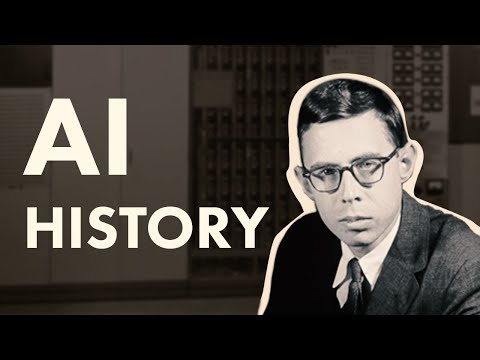

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo('Suevq-kZdIw')

Quem quiser se aprofundar em modelos de neurônios e do cérebro humano já que esse assunto está fora do escopo deste curso, sugerimos o livro

- W. Gerstner, W. M. Kistler, R. Naud, L. Paninski: *Neural Dynamics: from single neurons to networks and models of cognition*, Cambridge University Press, 2014.